In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
# pip install pyarrow and dask
import dask.dataframe as dd
import glob

In [3]:
import os 
os.chdir('C:/Users/edwin/OneDrive/Documents/GitHub/CHC')

In [4]:
def assign_lead_time_category(dataframe, variable_name, dataset_name, region_name=''):
  """Takes a dataframe and a variable name, and returns a dataframe with a column
  for the lead time category of the variable.

  Assumptions:
  Desired model has been converted to dataframe format
  You know the variable of interest to compute leads for, such as 'precip'

  The dataset_name argument makes the dataframe more readable and convenient for analysis

  Returns:
  A dataframe with a column for the lead category of the variable.
  """

  # Compute tercile thresholds
  short_lead = 2
  long_lead = 4

  # Classify precipitation using vectorized NumPy operations
  conditions = [
        dataframe[variable_name] < short_lead,
        dataframe[variable_name] >= long_lead
    ]
  choices = ["short", "long"]

  # Assign categories (default is "Medium")
  dataframe[f"lead_category"] = np.select(conditions, choices, default="medium")

  return dataframe

In [65]:
# Set dictionary of regions and their respective seasons of interest
seasons = {
    'eastern_east_africa':{
        'MAM': [3,4,5],
        'OND': [10,11,12]
    },
    'lake_victoria_basin':{
        'DJF': [12,1,2],
        'MAM': [3,4,5], 
        'SON': [9,10,11]
    },
    'west_africa':{
        'JAS': [7,8,9]
    },
    'south_sudan':{
        'MJJ': [5,6,7,8],
        'JAS': [7,8,9],
        'ASO': [8,9,10]
    },
    'eastern_ukraine':{
        'DJF': [12,1,2],
        'AMJ': [4,5,6],
        'JA': [7,8]
    },
    'southern_africa':{
        'DJF': [12,1,2],
        'FMA': [2,3,4]
    },
    'sri_lanka':{
        'ONDJ': [10,11,12,1]
    }
}


# Function to load in data and subset the data into the respective seasons
def generate_seasons_metrics(file_path_merged_netcdf, seasons_dict):
    df_dict = {}
    # extract the model and region from the file path of merged netcdf
    model = file_path_merged_netcdf.split('/')[-1].split('_')[-2]
    region = file_path_merged_netcdf.split('/')[-1].split('_')[0:-2]
    region = '_'.join(region)
    region = region.split("\\",1)[1]
    
    # open the merged netcdf, convert to a dataframe, and reset index
    current_netcdf = xr.open_dataset(file_path_merged_netcdf)
    current_df = current_netcdf.to_dataframe()
    current_df = current_df.reset_index().dropna()
    current_df = current_df[current_df['lead_time'] <= 6.5]
    # take the ensemble mean
    current_df = (current_df
                            .groupby(['time', 'lead_time', 'latitude', 'longitude'])[['predicted_precip', 'precip']]
                            .mean().reset_index())

    # take the spatial means
    current_df = (current_df  # Use the ensemble_means DataFrame
                              .groupby(['time', 'lead_time'])[['predicted_precip', 'precip']]
                              .mean().reset_index())
    
    # assign lead category to each lead time
    current_df = assign_lead_time_category(current_df, 'lead_time', model, region)
    
    # Subset the df into the respective seasons depending on the region
    for season, months in seasons_dict[region].items():
        df = current_df[current_df['time'].dt.month == months[0]].copy()

        # calculate correlation between predicted_precip and precip
        df.loc[:, 'season'] = season
        corr = df.groupby(['season', 'lead_category']).corr(method='spearman').drop(['precip'], axis = 1).droplevel(level = 2).reset_index()
        corr = corr.drop(['lead_time', 'time'], axis = 1)
        corr = corr.drop(corr.index[::2])
        corr = corr.rename(columns = {'predicted_precip': 'corr'})

        # Calculate mean and standard deviation
        stat = df.drop(['time', 'lead_time'], axis=1).groupby(['season', 'lead_category']).agg(['mean', 'std']).reset_index()
        stat.columns = ['season','lead_category', 'pred_mean', 'pred_std', 'actual_mean', 'actual_std']

        # Merging stat and spatial_means_corr to get 1 df with all values
        stat_clean = stat.merge(corr, left_on=['season', 'lead_category'], right_on=['season', 'lead_category'], how='left').dropna()

        # Calculating metrics
        stat_clean['potential_skill'] = np.square(stat_clean['corr'])
        stat_clean['conditional_bias'] = np.square(stat_clean['corr'] - (stat_clean['pred_std'] / stat_clean['actual_std']))
        stat_clean['unconditional_bias'] = np.square((stat_clean['pred_mean'] - stat_clean['actual_mean']) / stat_clean['actual_std'])
        stat_clean['skill_score'] = stat_clean['potential_skill'] - stat_clean['conditional_bias'] - stat_clean['unconditional_bias']

        stat_clean = stat_clean.drop(['pred_mean','pred_std','actual_mean','actual_std'], axis = 1)
        stat_clean['region'] = region
        stat_clean['model'] = model
        df_dict[f"{region}_{model}_{season}"] = stat_clean

    return pd.concat(df_dict.values(), ignore_index=True)
        



In [ ]:
# Initialize an empty dictionary to store DataFrames
dfs_dict = {}

# initiate file list
# list_of_files = glob.glob('/content/drive/My Drive/capstone_data/netCDF/*')
list_of_files = glob.glob('data/netCDF/southern_africa*')
# Loop over all files
for f in list_of_files:
    # Generate the DataFrame
    df = generate_seasons_metrics(f, seasons)

    # Store the DataFrame in the dictionary with the year as key
    dfs_dict[f] = df

# Concatenate all DataFrames in the dictionary into one DataFrame
final_df = pd.concat(dfs_dict.values(), ignore_index=True)


In [73]:
# group by lead category and season
final_df.groupby(['lead_category', 'season']).mean()

TypeError: agg function failed [how->mean,dtype->object]

ValueError: Index contains duplicate entries, cannot reshape

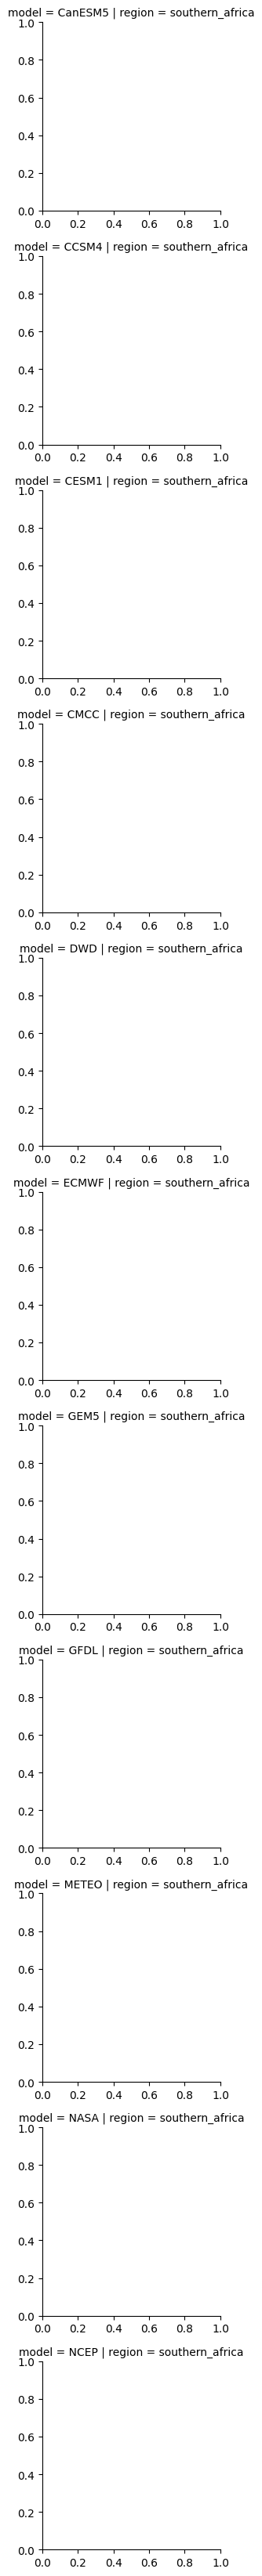

In [ ]:
def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index=args[1], columns=args[0], values=args[2])
    sns.heatmap(d, **kwargs, vmin=0, vmax=1,
                cmap=sns.color_palette('Reds', 10),
                annot=True,
                fmt=".2f",
                linewidths=0.1, linecolor='black')
    #plt.xticks(np.arange(0.5, 12.5, 1))  # Set xticks explicitly
    #plt.gca().set_xticklabels(np.arange(0.5, 12.5, 1))  # Set xticklabels
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    plt.gca().invert_yaxis()

fg = sns.FacetGrid(final_df, col='region', row='model', sharex=False, sharey=False)
fg.map_dataframe(draw_heatmap, 'lead_category', 'season', 'potential_skill', square = True)
fg.set_titles('Potential Skill \n Region={col_name} \n Model={row_name}')
fg.set_ylabels("Season")
fg.set_xlabels("Lead Category")
plt.show()